###Introduction and Problem framing

###Business Problem

A mobile app development company wants to understand what factors determine an app’s success on the Google Play Store so that they can improve future app launches and increase downloads. Using data such as category, rating, number of reviews, size, price, content rating, and app type, the goal is to analyze how these features influence user installs and identify patterns that separate high-performing apps from low-performing ones, helping the company make better decisions on app design, pricing, and market targeting.

### Description of the Dataset

Source : L. Gupta, "Google Play Store Apps," Feb 2019. [Online]. Available: https://www.kaggle.com/lava18/google-play-store-apps


Shape: This dataset was obtained as a raw CSV file containing 10,841 rows (including the header row) and 13 columns.


Uploaded to Kaggle: September 2018


Snapshot: Reflects app store state as of mid-2018

Column Meanings:
| Column             | Meaning                                                            |
| ------------------ | ------------------------------------------------------------------ |
| **App**            | Name of the application available on Google Play Store             |
| **Category**       | Main category the app belongs to (e.g., Game, Business, Education) |
| **Rating**         | Average user rating of the app (out of 5)                  |
| **Reviews**        | Total number of user reviews given to the app                      |
| **Size**           | Size of the app (e.g., 15M, 20M)                                   |
| **Installs**       | Number of times the app has been installed/downloaded              |
| **Type**           | Whether the app is **Free** or **Paid**                            |
| **Price**          | Cost of the app (0 if free)                                        |
| **Content Rating** | Target audience suitability (Everyone, Teen, Mature, etc.)         |
| **Genres**         | Specific subcategory/type of the app (more detailed than Category) |
| **Last Updated**   | Date when the app was last updated by the developer                |
| **Current Ver**    | Current version of the app available on the store                  |
| **Android Ver**    | Minimum Android version required to run the app                    |


### Analytical Questions Tackled:
1. Which app categories have the highest total installs, and what does this reveal about market demand?
2. Do free apps significantly outperform paid apps in terms of installs and user ratings?
3. What is the relationship between user ratings and number of installs — does a higher rated app always get more downloads?
4. How do app size and content rating influence user adoption across different categories?
5. What combination of features — category, type, size, and rating — characterizes the top 10% of high-performing apps by installs?

In [214]:
#Importing Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import statistics
from scipy import stats
from scipy.stats import linregress

### Data Loading and First looks of our DataFrame

In [215]:
#Data Loading
df = pd.read_csv('/content/googleplaystore.csv')

In [216]:
#First looks of data

#shape of DataFrame
print(df.shape,"\n")

#Data type of each category in our DataFrame
print(df.dtypes,"\n")

(10841, 13) 

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object 



In [217]:
#First 10 records of our DataFrame
df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [218]:
#Basic stats for all numeric columns
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


### Data Cleaning

First Step :
Let's check each column and find the unclean,unclear data and clean it

In [219]:
#(i): Category Column

df.Category.value_counts()
#we can observe that there is a value in category as "1.9" hence this record must be removed

,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384


In [220]:
#Deleting the record
df.drop(df[df["Category"] == "1.9"].index, inplace=True)

In [221]:
#(ii) : Reviews column


print(df['Reviews'].dtype)
# We can observe that the Reviews column is of "Object" datatype but it should be "integer" hence the datatype needs to be converted

object


In [222]:
#converting the datatype of "Reviews" feature :
df["Reviews"] = pd.to_numeric(df["Reviews"])

print(df['Reviews'].dtype)

int64


In [223]:
#(iii) : Size column :

df.Size.value_counts()
#There are few problems in Size column :
# 1) 15% of the column has "varies with device"
# 2) Size column has 2 types of units - (M,K)
# 3) Size column is of "Object datatype"

,count
Size,
Varies with device,1695
11M,198
12M,196
14M,194
13M,191
...,...
253k,1
992k,1
658k,1


In [224]:
# converting the Size of the app in kilobytes to megabytes
df["Size"] = df["Size"].apply(lambda x: str(round(float(x.replace("k", "")) / 1024, 2)) + "M" if "k" in str(x) else x)

# removing the "M" at last of each value in the "Size" column
df['Size'] = df.Size.str.replace("M","")

df.Size.value_counts()

,count
Size,
Varies with device,1695
11,198
12,196
14,194
13,191
...,...
0.48,1
0.56,1
0.18,1


In [225]:
#finding the median of "Size" column excluding "varies with device"

size_array = df[df["Size"] != "Varies with device"]["Size"].astype(float).to_numpy()
print(np.median(size_array))

13.0


In [226]:
#imputing the "Varies with device" variable with "median of data (13)"
df['Size'] = df.Size.replace("Varies with device","13")

#converting datatype of "Size" column from String -> Float
df['Size'] = pd.to_numeric(df.Size)

df.Size.dtype

dtype('float64')

In [227]:
#(iv) : Installs column

df.Installs.value_counts()
#Since Installs have the lower bound of number of installs of the app we can remove the "+" symbol at the end of data and change the column name as - "Installs Lower bound"
# Also change the datatype of "Installs" from "object" to "Integer"

,count
Installs,
"1,000,000+",1579
"10,000,000+",1252
"100,000+",1169
"10,000+",1054
"1,000+",907
"5,000,000+",752
100+,719
"500,000+",539
"50,000+",479


In [228]:
#Replacing 'Installs' column to 'Installs_LB' indicating the lower bound of number of installs of the app
df.rename(columns = {'Installs':'Installs_LB'},inplace = True)

#Replacing various signs like "+" , "," so we further convert to numeric datatype
df['Installs_LB'] = df.Installs_LB.str.replace("+","")
df['Installs_LB'] = df.Installs_LB.str.replace(",","")

#Converting datatype of "Installs_LB" from "String" to "Integer"
df['Installs_LB'] = pd.to_numeric(df.Installs_LB)

In [229]:
#(v) : Type column :
# Create a new column where Free -> 0 and paid is -> 1

df.Type.value_counts()

,count
Type,
Free,10039
Paid,800


In [230]:
#Creating new feature 'Type_num' with free -> 0 and paid -> 1
df['Type_num'] = df.Type.map({"Free" : 0,"Paid" : 1})

print(df.Type_num.value_counts())
df.info()

Type_num
0.0    10039
1.0      800
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  float64
 5   Installs_LB     10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
 13  Type_num        10839 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 1.2+ MB


In [231]:
#(vi) : Price Column

#Price column has "$" symbol which has been removed
df['Price'] = df.Price.str.replace('$','')

#Datatype of Price has been changed from "Object" to "Float"
df['Price'] = pd.to_numeric(df.Price)

In [232]:
#(vii) : Content Rating column

#Everything is good in content rating except that the values in the column aren't named properly
df['Content Rating'].value_counts()

#Replacing the names in Content rating with good ones :
df["Content Rating"] = df["Content Rating"].replace({
    "Everyone": "General",
    "Teen": "Teens(13+)",
    "Mature 17+": "Mature(17+)",
    "Everyone 10+": "Kids(10+)",
    "Adults only 18+": "Adults(18+)",
    "Unrated": "Not Rated"
})

In [233]:
#(viii) : Genres column


#converting all the app genres into its first main genre
df["Genres"] = df["Genres"].apply(lambda x: str(x).split(";")[0])

In [234]:
#(ix) : Last Updated column

#covering Last Updated column from "String" , "datetime" datatype
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

print(df['Last Updated'].dtype)

datetime64[ns]


In [235]:
#(x) : Current ver column :

#Since 13% of values in "Current ver" column are "Varies with device" we can replace with null values
df["Current Ver"] = df["Current Ver"].replace("Varies with device", np.nan)

In [236]:
#(xi) : Android ver Column

df['Android Ver'] = df['Android Ver'].replace("Varies with device", np.nan)

df['Android Ver'] = df['Android Ver'].str.replace("W", "")

Second Step : Handling Missing Values

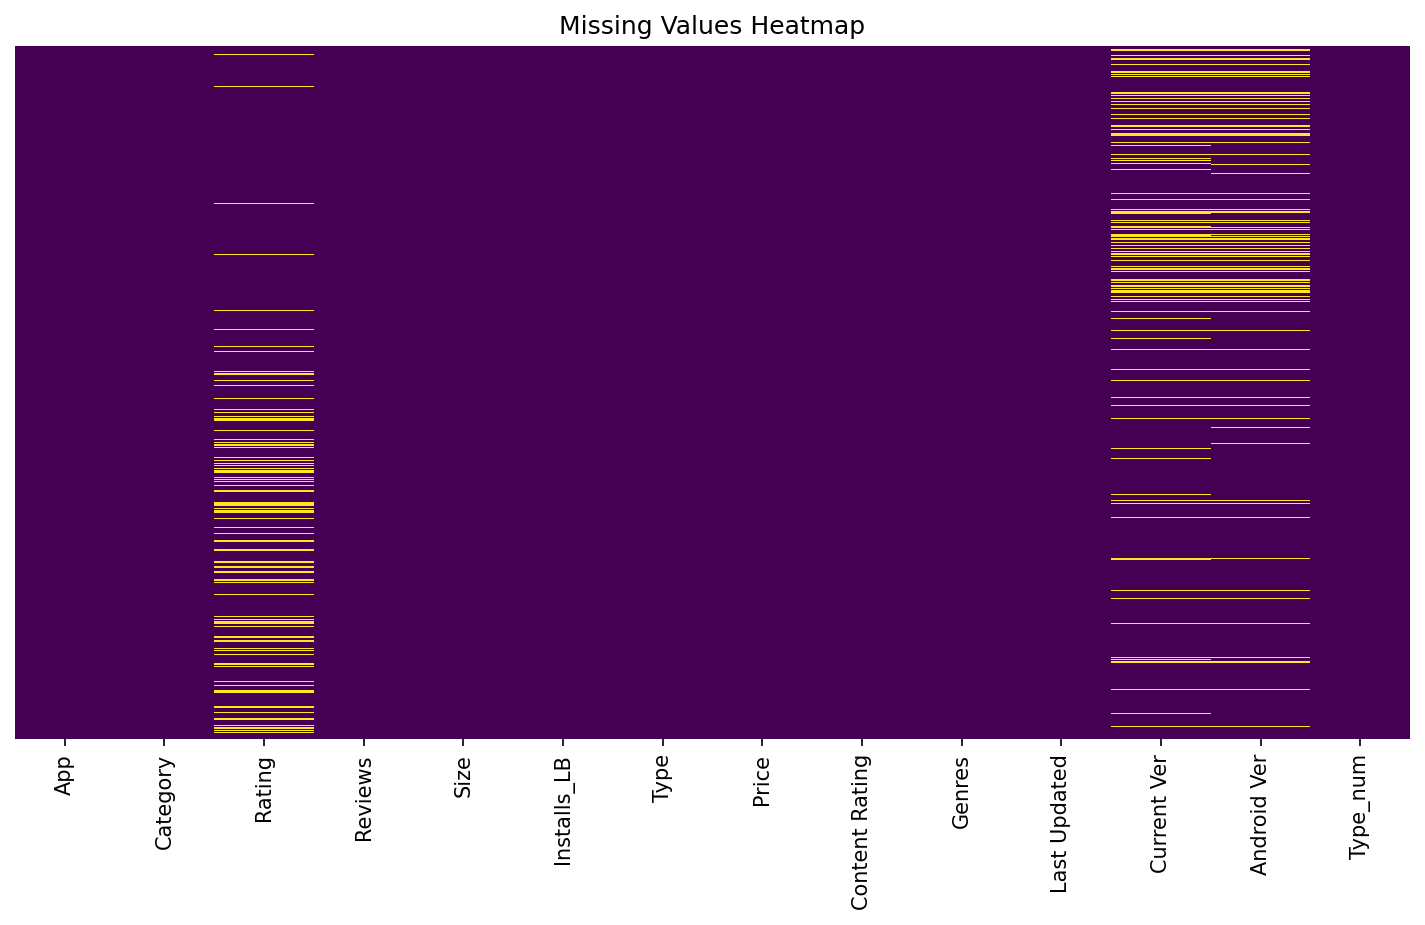

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs_LB,0
Type,1
Price,0
Content Rating,0
Genres,0


In [237]:
#Detecting Missing or Null values in each column

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

df.isnull().sum()

#Therefore the missing values are in :
#Rating : 1474 out of 10839(13%)
#Type : 1 out of 10839(<0.01%)
#Current ver : 1467 out of 10839(13.5%)
#Android ver : 1364 out of 10839(12.58%)
#Type_num : 1 out of 10839(<0.01%)

In [238]:
#(i) : Handling missing values in Rating column :
df["Rating"] = df["Rating"].fillna(
    df.groupby("Category")["Rating"].transform("median")
)
#category wise median imputation of null values has been done
print("After:", df['Rating'].isnull().sum())

After: 0


In [239]:
#(ii) : Handling missing values in Type column and Type_num column :

#Replacing it with mean
df['Type'] = df["Type"].fillna(df["Type"].mode()[0])
df['Type_num'] = df['Type_num'].fillna(0.0)

Step Three : Handling Duplicate

In [240]:
#There are exactly 483 duplicate records
print(df.duplicated().sum())

483


In [241]:
#Type 1 — Exact full row duplicates handling
df = df.drop_duplicates()

#Type 2 — Same app name, different values
#Same app scraped multiple times with slightly different review counts or ratings. For these, keep the row with the highest reviews as it's the most recent snapshot:
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset='App', keep='first')

df = df.reset_index(drop=True)

In [242]:
#successfully all duplicates has been dropped
#New dataframe is of size as follows :
df.shape

(9659, 14)

*Step* Four : Detect and Treat Outliers

In [243]:
#(i) : Rating column  Outlier Detection and Treatment

#Checking if any rating Exceeds 5.0
print(df[df['Rating'] > 5])


print(df['Rating'].describe())

#Checking Null Values in Rating  Column
print(df['Rating'].isnull().sum())

#Rating Column is clean with no Outliers

Empty DataFrame
Columns: [App, Category, Rating, Reviews, Size, Installs_LB, Type, Price, Content Rating, Genres, Last Updated, Current Ver, Android Ver, Type_num]
Index: []
count    9659.000000
mean        4.192701
std         0.497177
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64
0


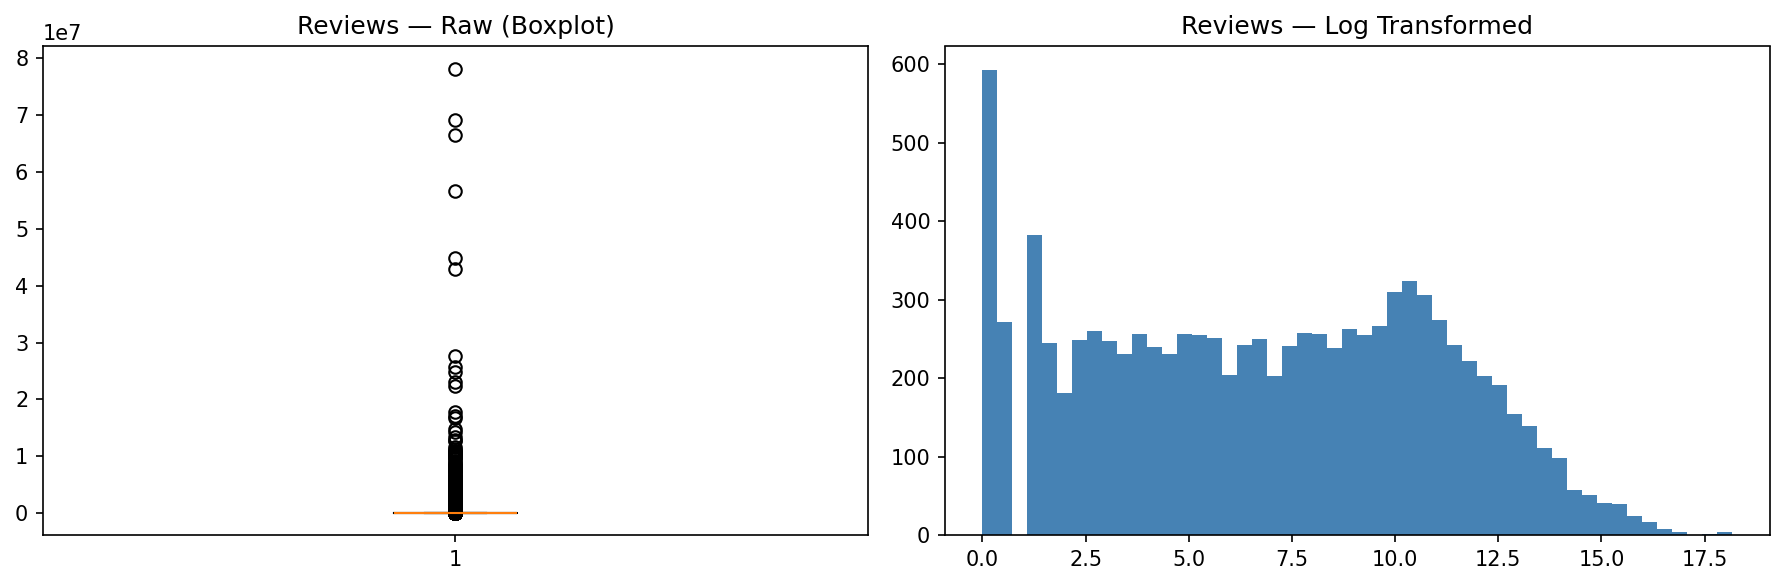

In [244]:
# (ii) : Reviews Column Outlier detection and treatment :

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before log transform
axes[0].boxplot(df['Reviews'].dropna())
axes[0].set_title('Reviews — Raw (Boxplot)')

# After log transform
axes[1].hist(np.log1p(df['Reviews'].dropna()), bins=50, color='steelblue')
axes[1].set_title('Reviews — Log Transformed')

plt.tight_layout()
plt.show()

#Applied log transformation (log1p) for visualization purposes
df['Reviews_log'] = np.log1p(df['Reviews'])

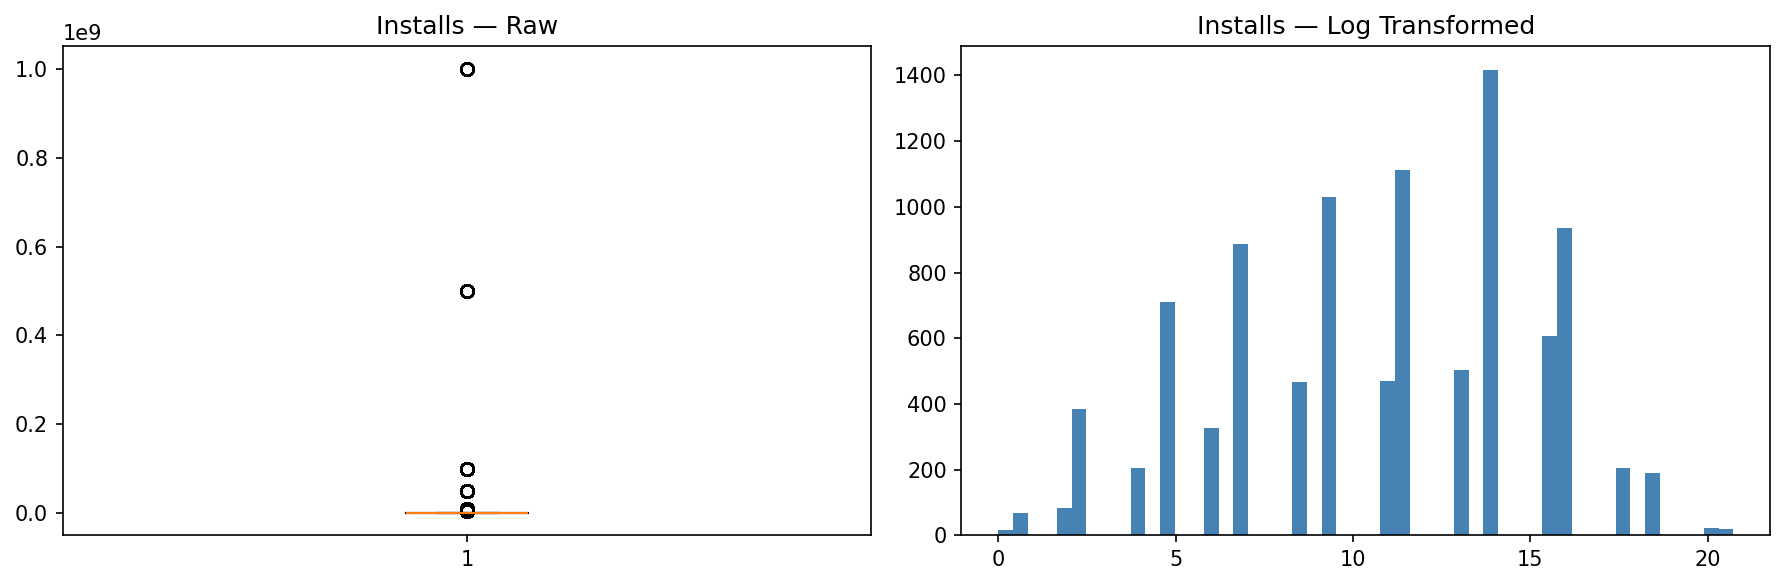

In [245]:
# (iii) : Installs_LB Column Outlier detection and treatment :
df['Installs_log'] = np.log1p(df['Installs_LB'])

# Quick check
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Installs_LB'].dropna())
axes[0].set_title('Installs — Raw')

axes[1].hist(df['Installs_log'].dropna(), bins=50, color='steelblue')
axes[1].set_title('Installs — Log Transformed')

plt.tight_layout()
plt.show()

In [246]:
#Finally Data Cleaning Part is done now it's time for analysis of data the cleaned dataset looks like this :

df.head()

,App,Category,Rating,Reviews,Size,Installs_LB,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Type_num,Reviews_log,Installs_log
0,Facebook,SOCIAL,4.1,78158306,13.0,1000000000,Free,0.0,Teens(13+),Social,2018-08-03,NaN,NaN,0.0,18.174247,20.723266
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,13.0,1000000000,Free,0.0,General,Communication,2018-08-03,NaN,NaN,0.0,18.051345,20.723266
2,Instagram,SOCIAL,4.5,66577446,13.0,1000000000,Free,0.0,Teens(13+),Social,2018-07-31,NaN,NaN,0.0,18.013876,20.723266
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,13.0,1000000000,Free,0.0,General,Communication,2018-08-01,NaN,NaN,0.0,17.852342,20.723266
4,Clash of Clans,GAME,4.6,44893888,98.0,100000000,Free,0.0,Kids(10+),Strategy,2018-07-15,10.322.16,4.1 and up,0.0,17.619812,18.420681


### UNIVARIATE ANALYSIS

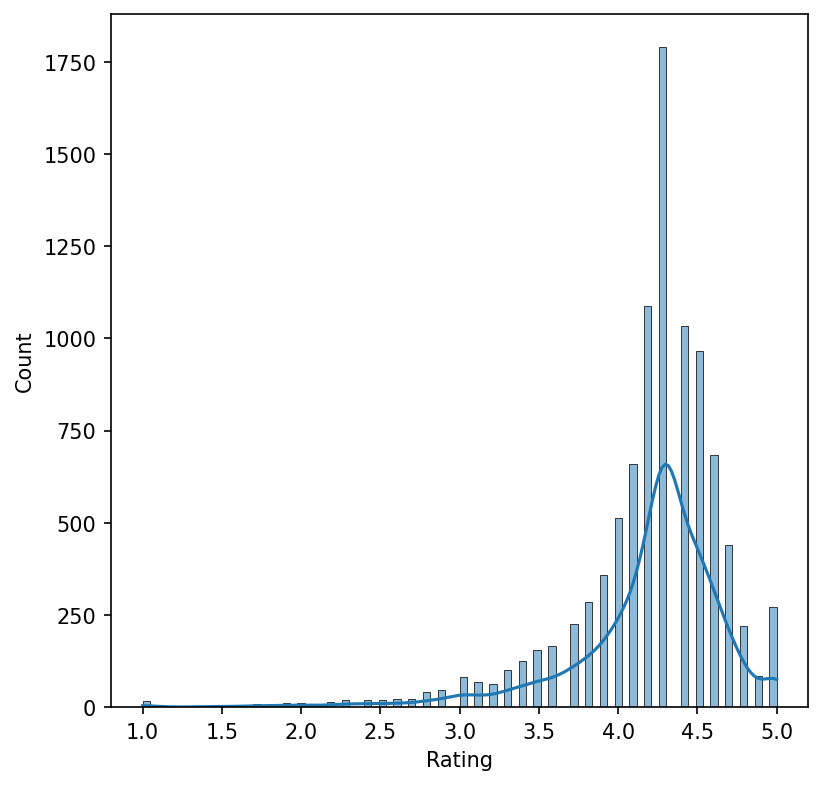

Skewness :  -1.9689740765921686


In [247]:
#Rating Distribution

plt.figure(figsize = (6,6))
sns.histplot(
    x='Rating',
    data=df,
    stat='count',
    multiple='dodge',
    kde=True
)
plt.show()

print("Skewness : ",df.Rating.skew())


Important insight :

The ratings data is negatively skewed

Most of the observations fall between 4.0 and 4.5

This skew reflects real-world behavior on the Play Store:
satisfied users are more likely to leave ratings, and
poorly rated apps are often removed by Google


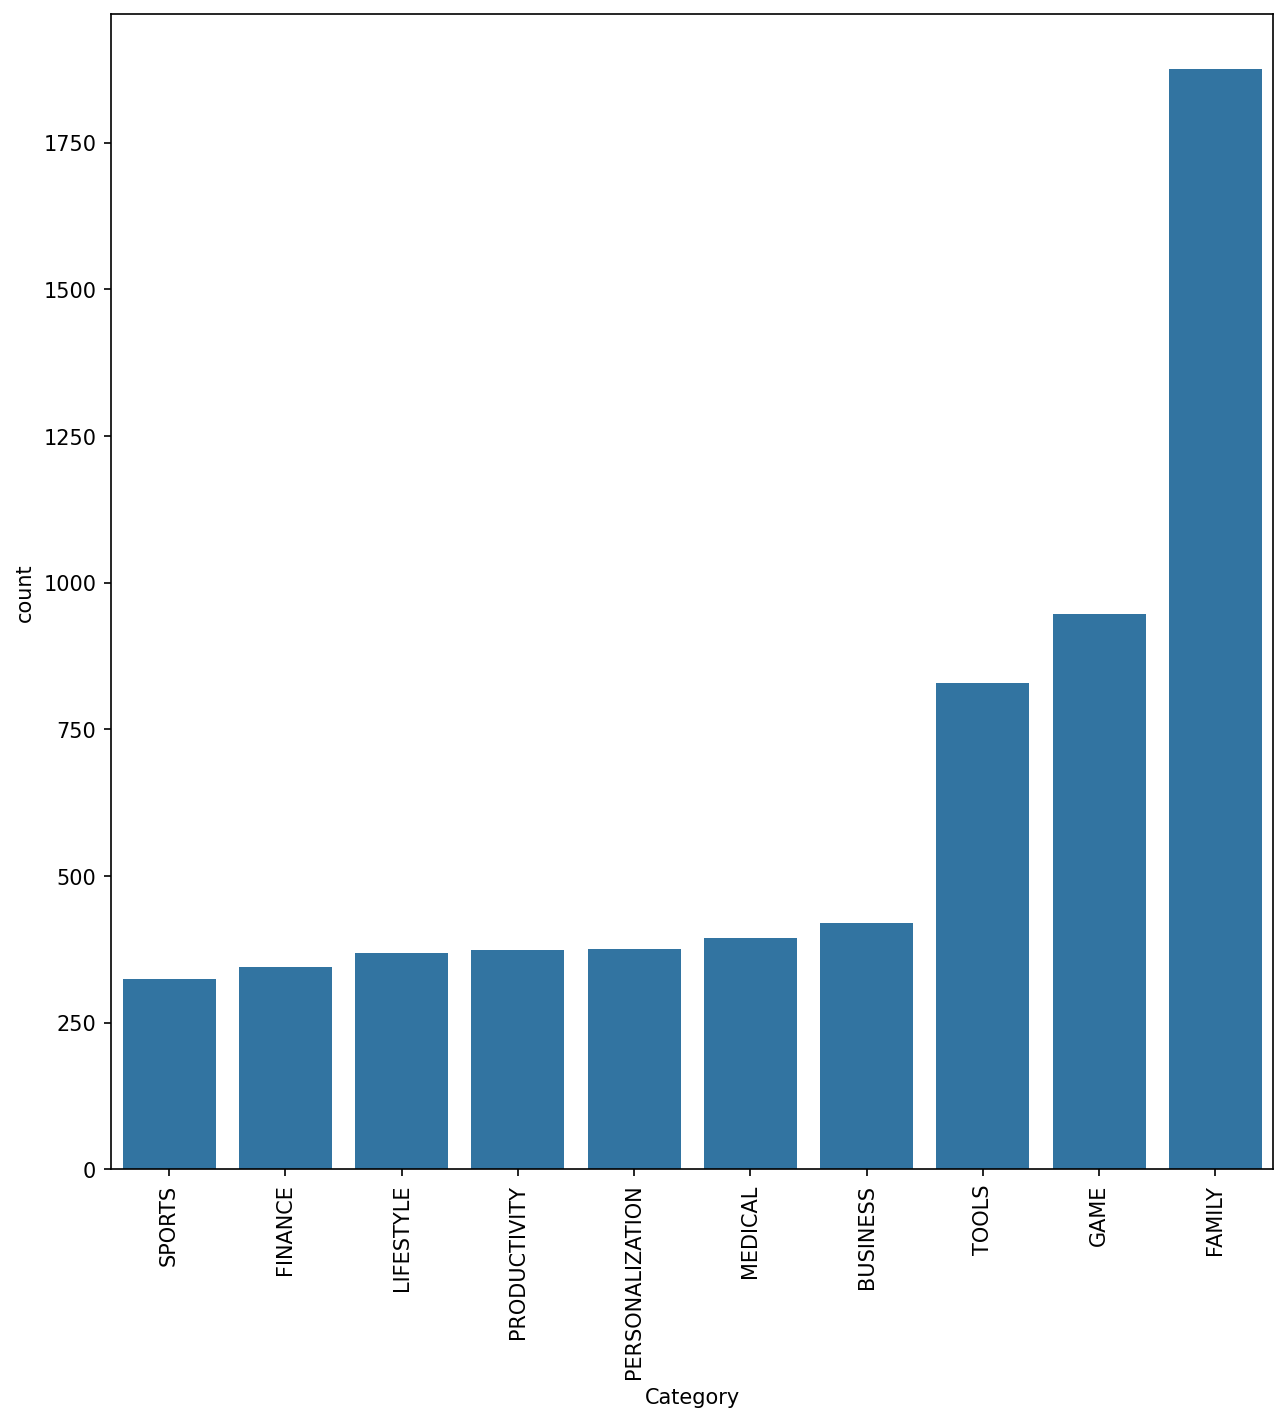

In [248]:
#Category Feature distribution
order = df['Category'].value_counts().head(10).sort_values().index

plt.figure(figsize=(10,10))
sns.countplot(data=df, x='Category', order=order)

plt.xticks(rotation=90)
plt.show()

Important Insight:

**1. Market Dominance:**
"FAMILY" category leads with 1875 apps, followed by "GAME" and "TOOLS,
collectively accounting for 37.79% of the entire dataset.

**2. Saturation Risk:**
The top 3 categories are heavily saturated — a new app here would
compete with 3000+ existing products making discoverability difficult.

**3. Opportunity Zones:**
 "PRODUCTIVITY" , "LIFESTYLE" , "FINANCE" , "SPORTS" categories show meaningful demand with comparatively fewer apps,
suggesting lower competition and better chances of visibility.

**4. Business Recommendation:**
For a mobile app development company looking to maximize installs,
targeting mid-tier categories with high utility value offers a
better risk-to-reward ratio than entering already dominant categories.

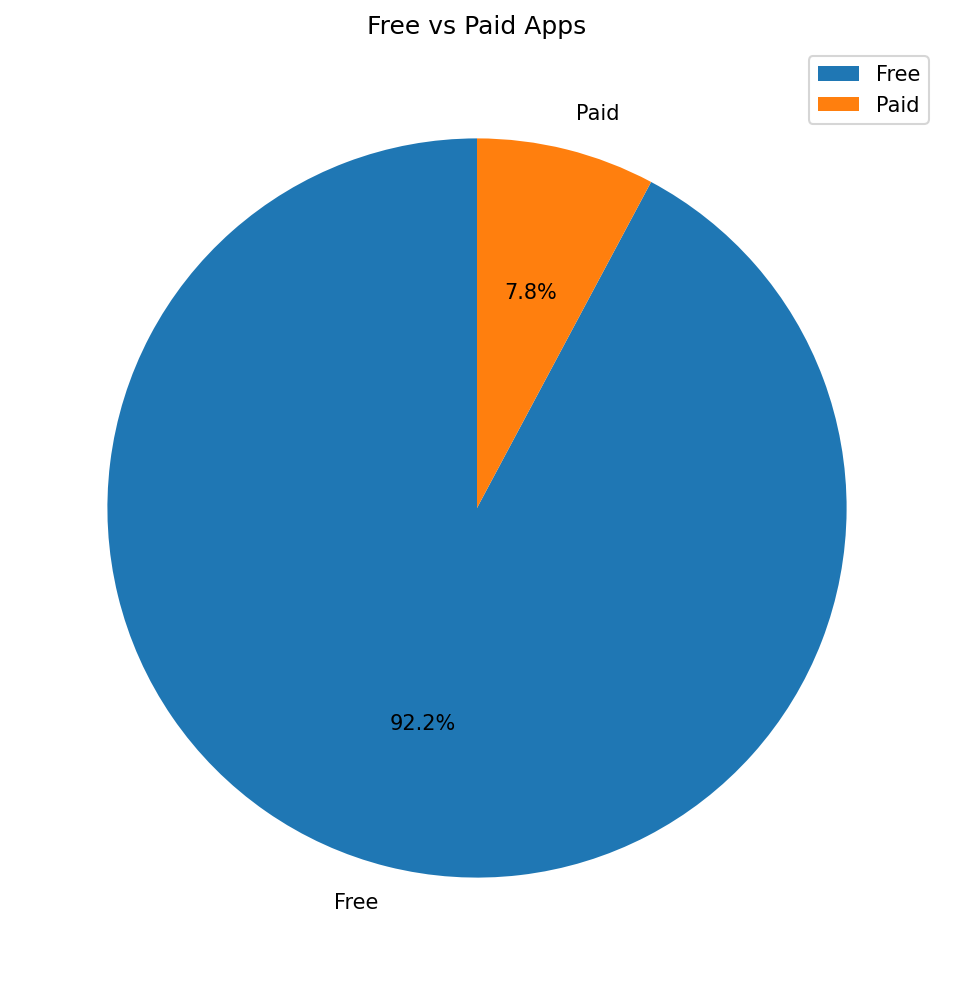

In [249]:
#Type feature distribution :

df1 = df.Type_num.value_counts()

plt.figure(figsize=(8,8))
plt.pie(df1,labels=['Free','Paid'], autopct='%1.1f%%',startangle=90)
plt.legend()
plt.title("Free vs Paid Apps")
plt.show()

Important Insight:

FREE Apps make upto 92.2% of the dataset showing clear domination in the market
meanwhile, PAID apps only make upto 7.8% of the dataset


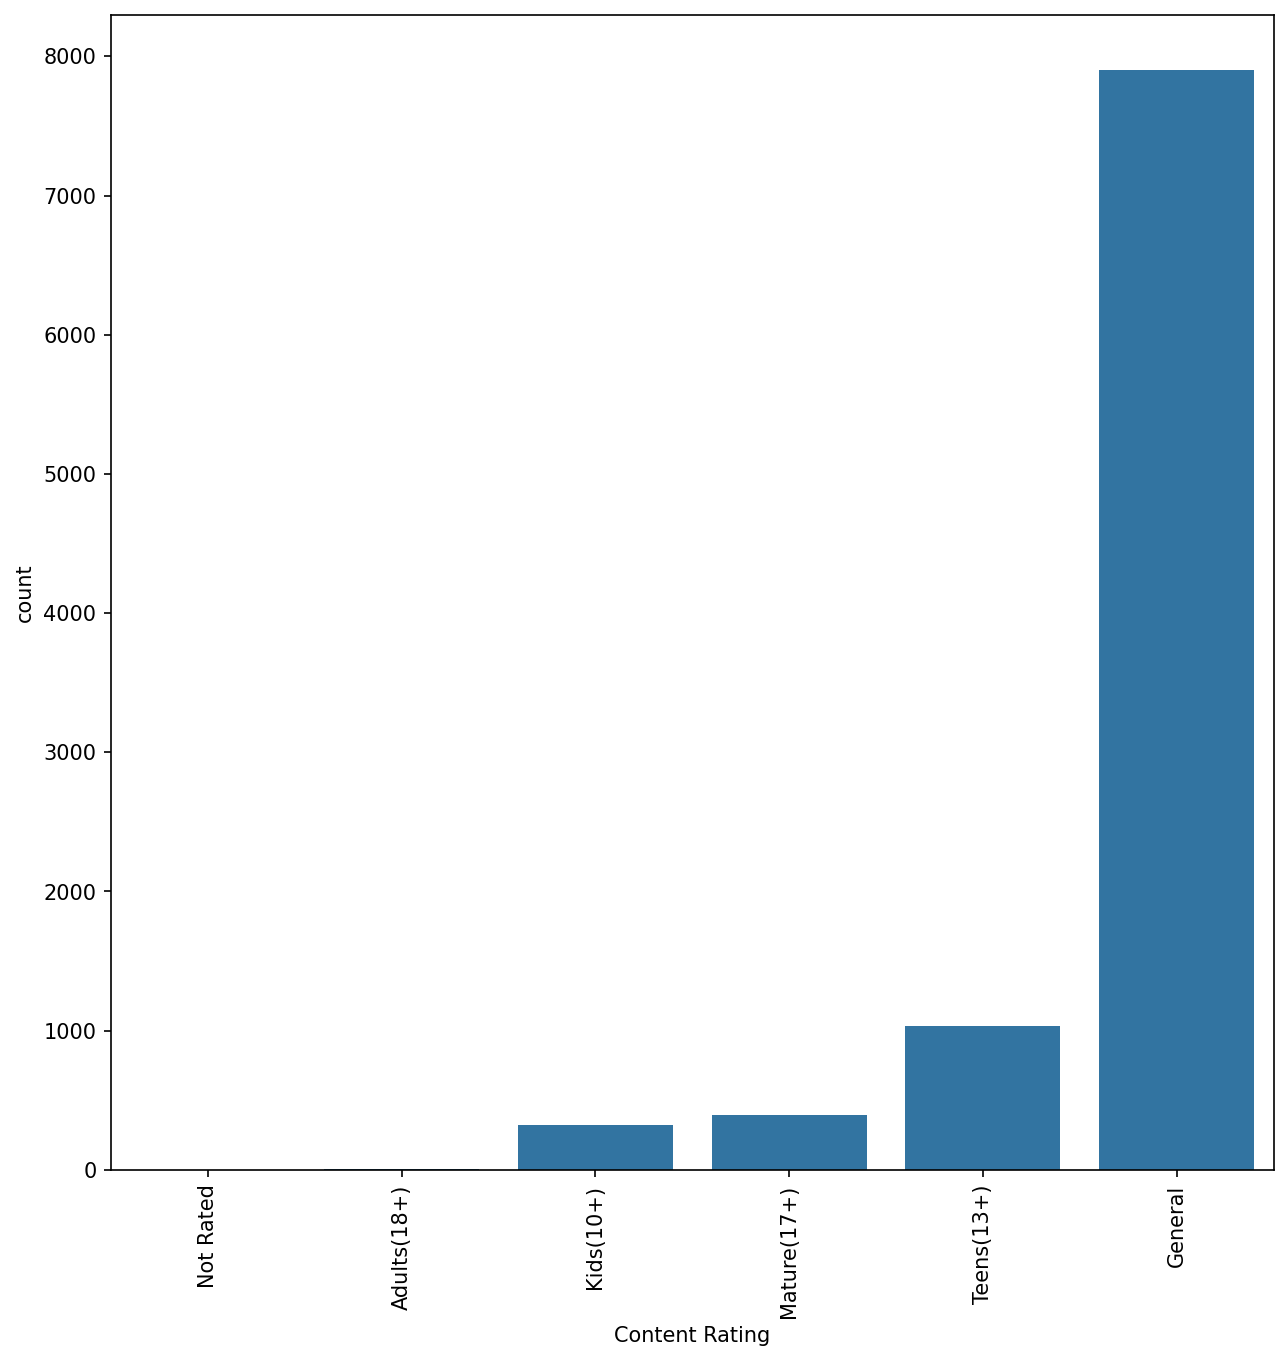

In [250]:
# "Content Rating" Feature Distribution

order = df['Content Rating'].value_counts().sort_values().index

plt.figure(figsize=(10,10))
sns.countplot(data=df, x='Content Rating', order=order)

plt.xticks(rotation=90)
plt.show()

Important insight  :

81.8% of apps in the Play Store are made for General Audience followed by Teens(10%) and Mature Audience(4%)

Market shows a high liking of an App's success if it is made for all the Audience

A decent amount of apps are also  made for Teens which shows a possibility of target audience which are "Teens"

### BIVARIATE AND MULTIVARIATE ANALYSIS

=== Average Rating: Free vs Paid ===
Type
Free    4.19
Paid    4.28
Name: Rating, dtype: float64

=== Rating Count: Free vs Paid ===
Type
Free    8905
Paid     754
Name: Rating, dtype: int64

=== Median Rating: Free vs Paid ===
Type
Free    4.30
Paid    4.35
Name: Rating, dtype: float64


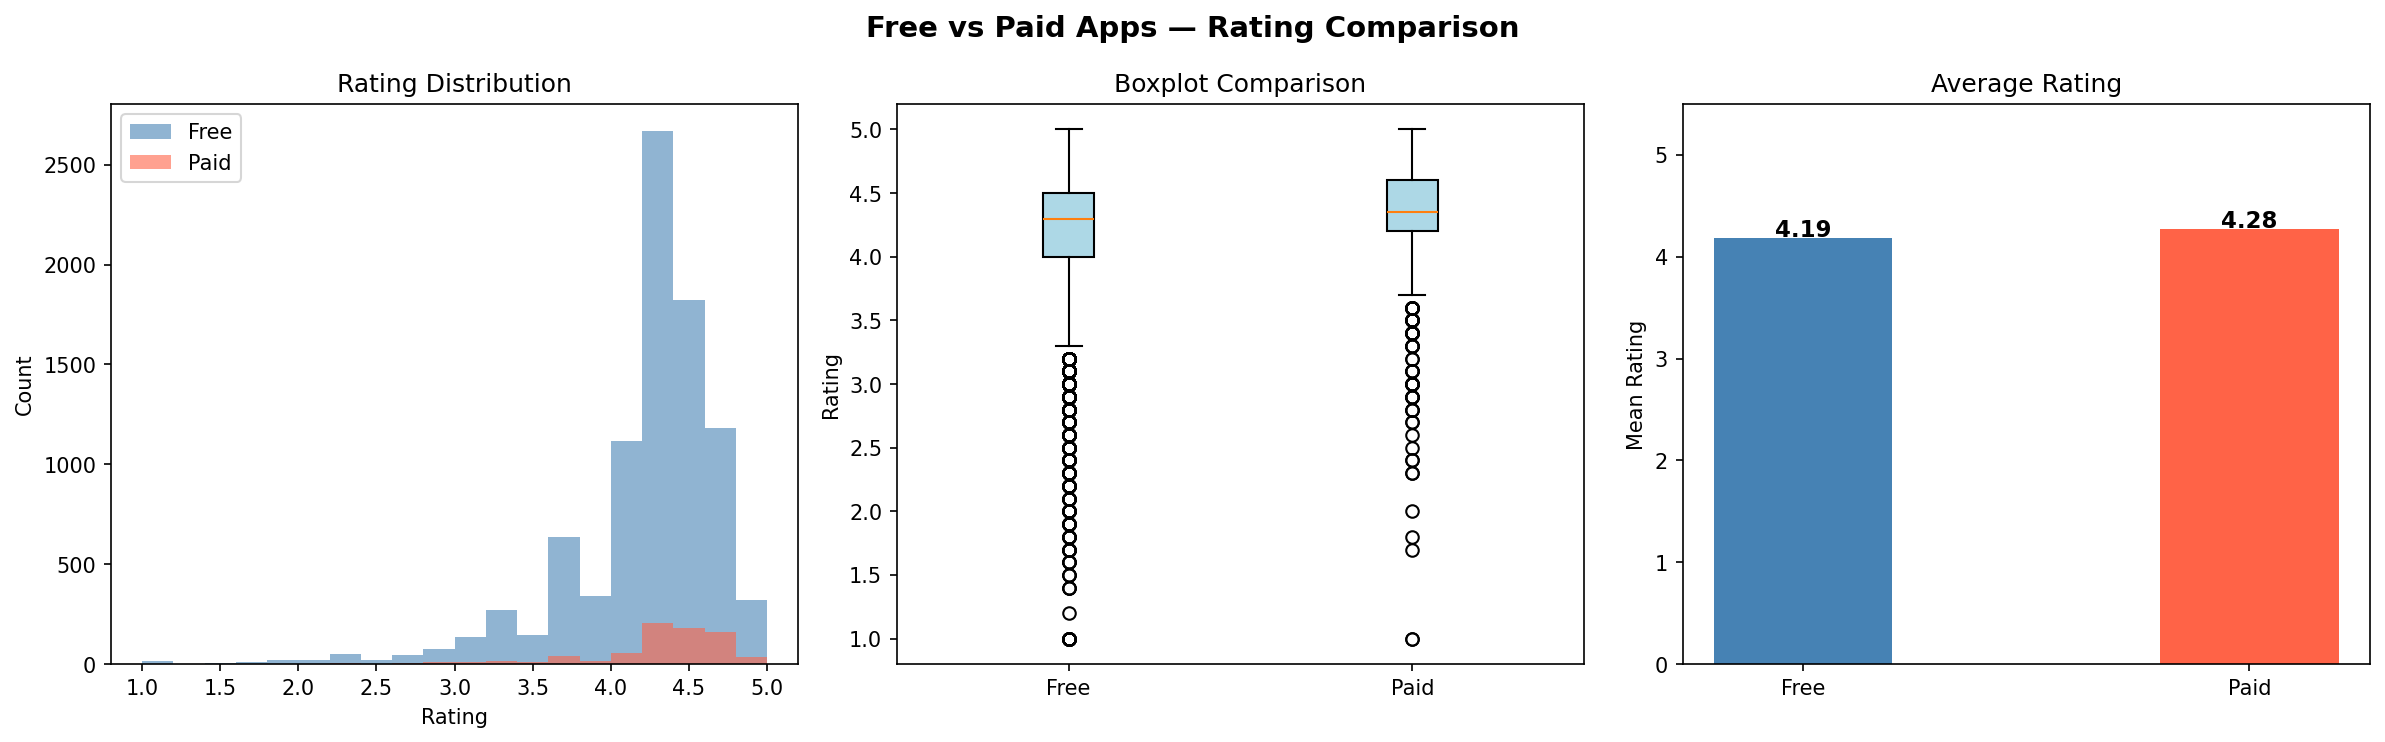


=== T-Test Result ===
T-statistic : -4.8119
P-value     : 0.0000
✅ Difference IS statistically significant (p < 0.05)


In [251]:
#Rating comparision of free and paid apps

print("=== Average Rating: Free vs Paid ===")
print(df.groupby('Type')['Rating'].mean().round(2))

print("\n=== Rating Count: Free vs Paid ===")
print(df.groupby('Type')['Rating'].count())

print("\n=== Median Rating: Free vs Paid ===")
print(df.groupby('Type')['Rating'].median().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Free vs Paid Apps — Rating Comparison', fontsize=14, fontweight='bold')

free = df[df['Type'] == 'Free']['Rating'].dropna()
paid = df[df['Type'] == 'Paid']['Rating'].dropna()

# Plot 1 — Histogram overlay
axes[0].hist(free, bins=20, alpha=0.6, color='steelblue', label='Free')
axes[0].hist(paid, bins=20, alpha=0.6, color='tomato', label='Paid')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2 — Boxplot
df_clean = df[df['Type'].isin(['Free', 'Paid'])].dropna(subset=['Rating'])
groups = [df_clean[df_clean['Type'] == t]['Rating'].values for t in ['Free', 'Paid']]
axes[1].boxplot(groups, tick_labels=['Free', 'Paid'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot Comparison')
axes[1].set_ylabel('Rating')

# Plot 3 — Mean bar chart
means = df.groupby('Type')['Rating'].mean().reindex(['Free', 'Paid'])
bars = axes[2].bar(means.index, means.values, color=['steelblue', 'tomato'], width=0.4)
for bar, val in zip(bars, means.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Average Rating')
axes[2].set_ylabel('Mean Rating')
axes[2].set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

# --- 3. Statistical significance test ---


t_stat, p_value = stats.ttest_ind(free, paid)
print(f"\n=== T-Test Result ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
if p_value < 0.05:
    print("✅ Difference IS statistically significant (p < 0.05)")
else:
    print("❌ Difference is NOT statistically significant (p >= 0.05)")

Important Insight:

1)Most applications on the Play Store are free apps, indicating that the freemium business model dominates the mobile app market.

2)Paid apps have slightly higher average and median ratings than free apps, suggesting that paid applications may provide better user experience or quality. Statistical testing confirmed that this difference is significant (p < 0.05).

3)The majority of both free and paid apps are highly rated, with ratings concentrated between 4.0 and 4.5, showing that most apps on the platform maintain generally positive user satisfaction.

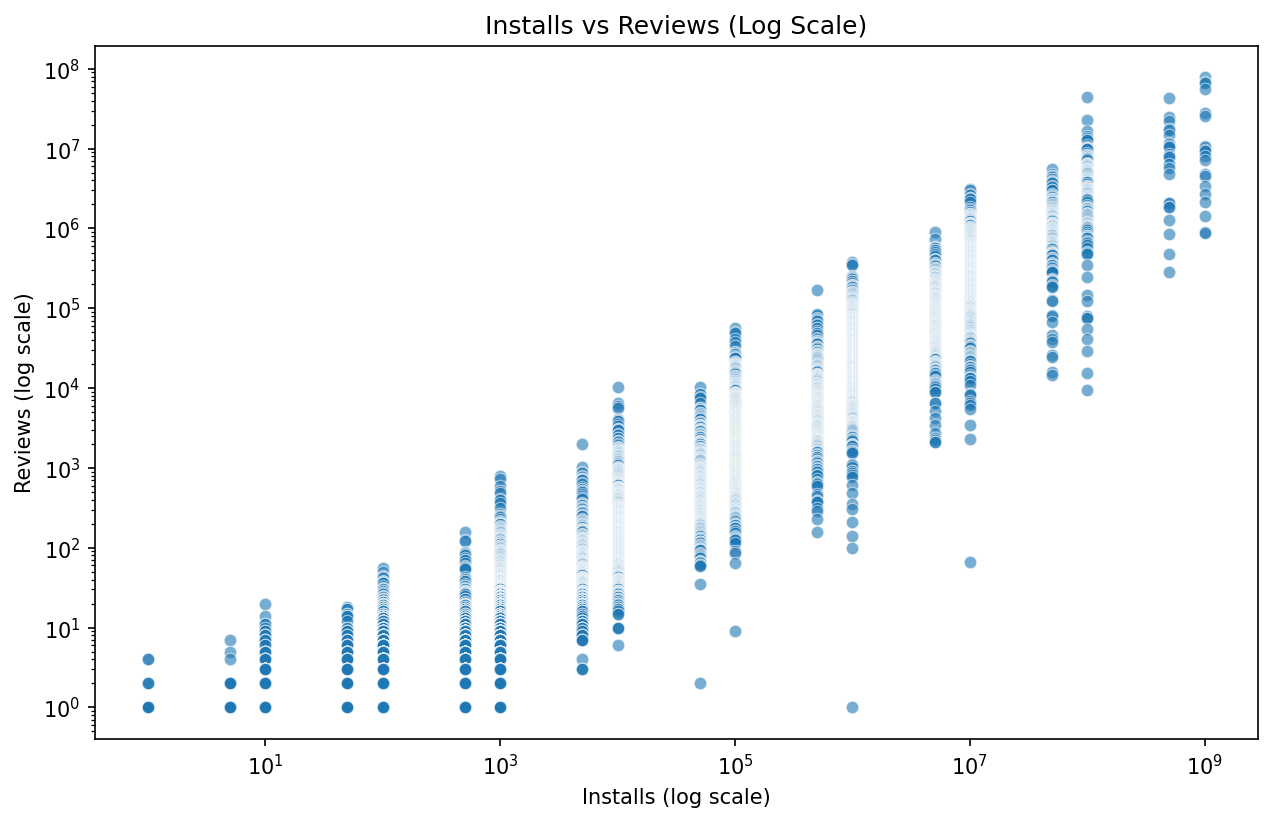

In [252]:
#Installs v/s reviews Scatter plot with log scale

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Installs_LB',
    y='Reviews',
    alpha=0.6
)

# Log scale
plt.xscale('log')
plt.yscale('log')

plt.title('Installs vs Reviews (Log Scale)')
plt.xlabel('Installs (log scale)')
plt.ylabel('Reviews (log scale)')

plt.show()

Important Insights:

1)Apps with higher installs generally receive more reviews, showing a strong positive relationship between popularity and user engagement.

2)A small number of apps dominate the market with extremely high installs and reviews, while most apps remain in the low-install range.

3)Some apps have high installs but relatively fewer reviews, indicating opportunities to improve user engagement and feedback collection.

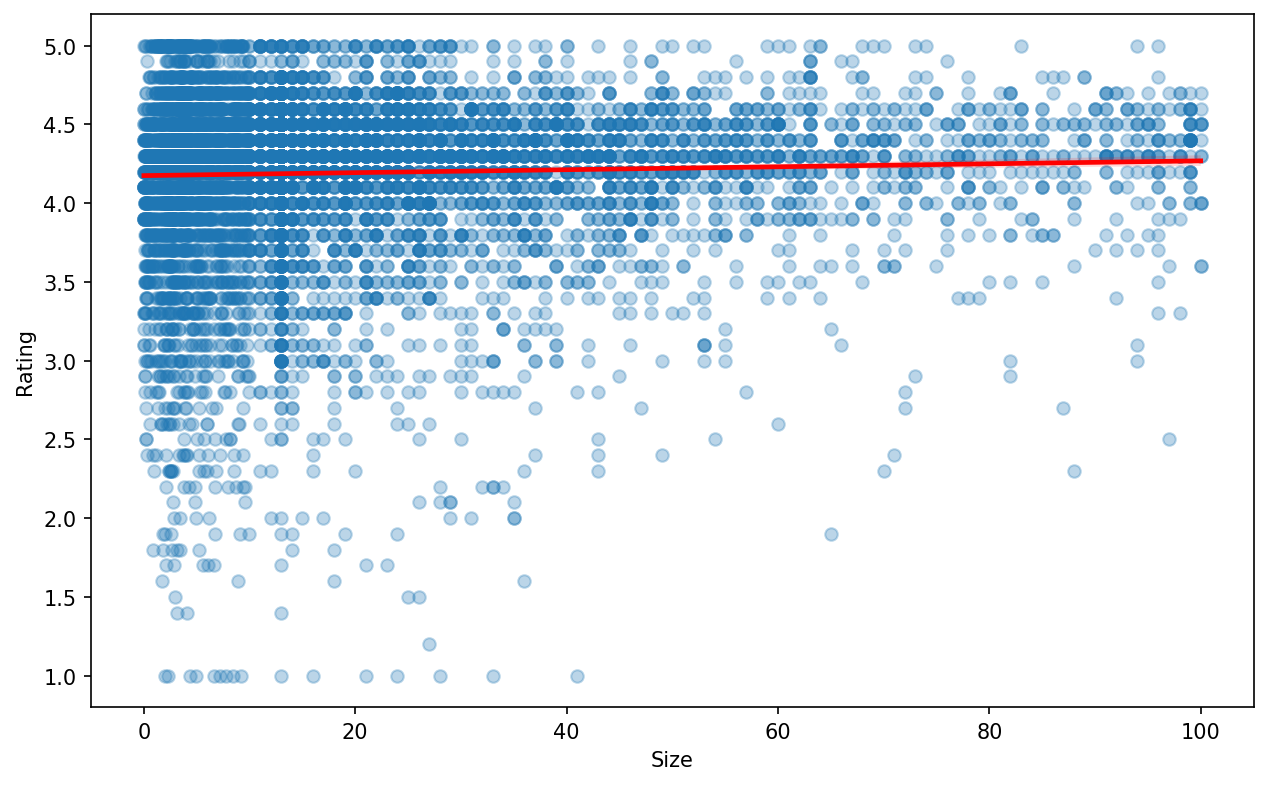

Slope: 0.0009359121392476184


In [253]:
#Size v/s Ratings Scatter plot with Regression Line
sns.regplot(
    data=df,
    x='Size',
    y='Rating',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.show()

#To find slope of the Regression Line
result = linregress(df_clean['Size'], df_clean['Rating'])
print("Slope:", result.slope)

Important Insights:

The regression line is nearly flat (slope ≈ 0), indicating negligible
correlation between app size and user rating.

- Users rate apps based on experience and utility, not storage footprint
- A well-designed lightweight app can achieve ratings comparable to
  large feature-heavy apps

Business Reccomendation:

Our app development company should not equate larger app size with
better user perception. Prioritizing a smooth, lightweight experience
may yield equally strong ratings while improving accessibility for
users with low storage devices — particularly relevant in markets
like India where mid-range devices dominate.

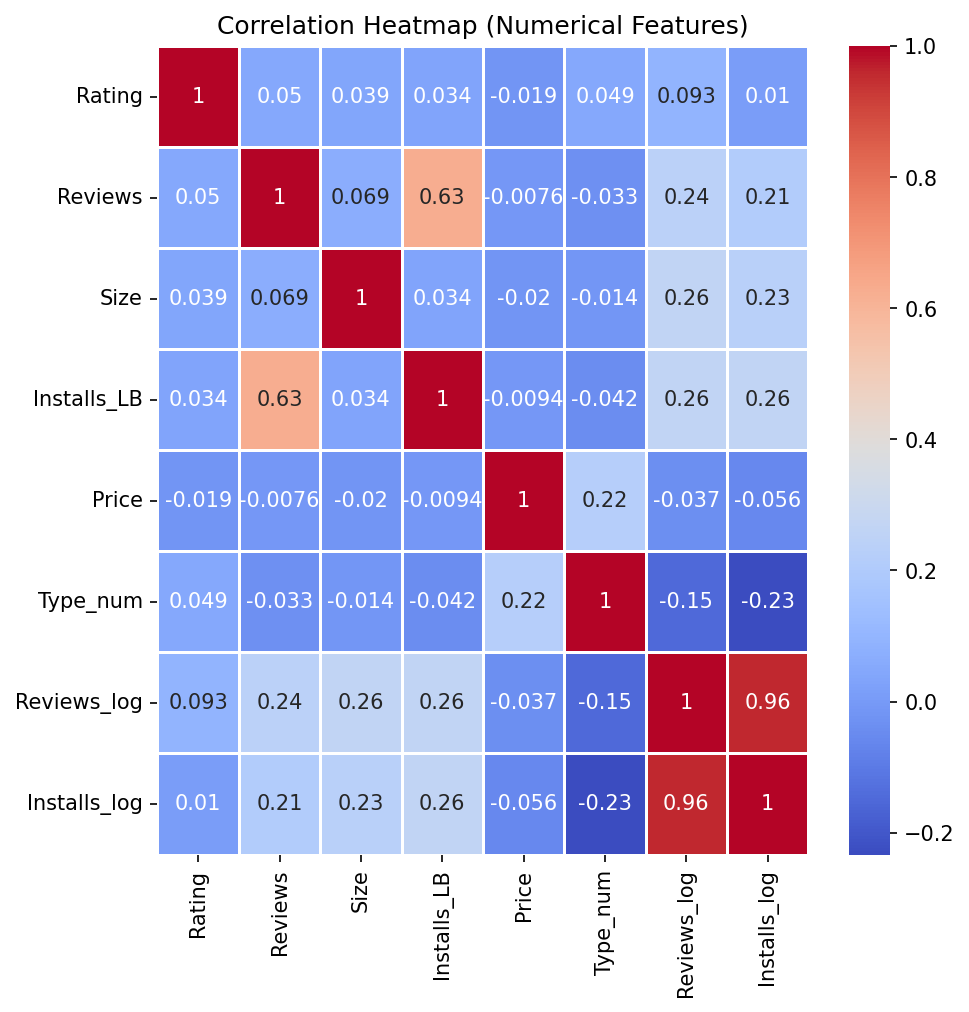

In [254]:
#Correlation HeatMap :

# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(7,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

Important Insights:

Important Correlations to be considered:

Reviews ↔ Installs_LB (0.63) — Apps with more installs tend to have far more reviews. This makes intuitive sense and suggests install count is a good proxy for engagement volume.

Reviews_log ↔ Installs_log (0.96) — An extremely strong relationship. Once you log-transform both, installs and reviews move almost in lockstep. This tells you the relationship is multiplicative/exponential in raw form.

Type_num ↔ Installs_log (-0.23) and Type_num ↔ Reviews_log (-0.15) — Paid apps (higher Type_num) tend to have fewer installs and reviews, which is expected.

### CONCLUSION:

### KEY INSIGHTS AND BUSINESS RECOMMENDATIONS:

### TOP 5 OVERALL FINDINGS:

1. User Ratings are Naturally Optimistic
Most apps rate between 4.0–4.5 with a left skew — reflecting real platform behavior where satisfied users rate more and poorly rated apps get removed by Google.

2. Market is Heavily Concentrated
FAMILY, GAME and TOOLS dominate with 37.79% of all apps — making these categories extremely saturated. Mid-tier utility categories like MEDICAL and BUSINESS offer lower competition with meaningful demand.

3. Freemium is the Dominant Business Model
92.2% of apps are free — but interestingly paid apps show slightly higher average ratings (statistically significant, p < 0.05), suggesting paid apps deliver marginally better user experience.

4. General Audience is the Biggest Market
81.8% of apps target everyone — but Teens (10%) represent an underleveraged segment worth targeting for focused app strategies.

5. Installs Drive Engagement — Not the Other Way
Reviews and installs are almost perfectly correlated after log transformation (r = 0.96) — meaning popularity fuels engagement. Some high-install apps have disproportionately low reviews, signaling missed engagement opportunities.

6. App Size is Irrelevant to Quality
Regression line between size and rating is nearly flat — users judge apps on experience, not size. Lightweight apps compete equally with large ones — critical insight for emerging markets like India.

### ACTIONABLE RECOMMENDATIONS:

1. Target Underleveraged Categories

Avoid oversaturated categories like Family and Game. Focus on Medical, Business or Productivity where competition is lower but user intent is high — better discoverability with fewer resources.


2. Go Freemium — But Invest in Quality

Launch free to maximize installs, but invest heavily in core experience. Since paid apps statistically rate higher (p < 0.05), quality is what drives long term retention and monetization potential.


3. Optimize Performance Not Size

App size has negligible impact on ratings — users care about experience not storage. Build lightweight, fast, bug-free apps — especially important for emerging markets like India where mid-range devices dominate.

### FURTHER ANALYSIS:


1. Sentiment Analysis on User Reviews
Since you found that reviews and installs are strongly correlated, analyzing the tone of reviews (positive/negative/neutral) could reveal what users actually love or hate about top performing apps — going beyond just the numbers.
2. Time Series Analysis
Using the Last Updated column to analyze how app ratings and installs change over time — do recently updated apps perform better? This could guide update frequency strategy.
3. Price Sensitivity Analysis
Deeper dive into paid apps — at what price point do installs drop significantly? This could help the company find the sweet spot for premium pricing.

###FUTURE MODELS:

1. Install Prediction Model
Using features like Category, Rating, Size, Type and Reviews to predict install range of a new app before launch — directly useful for the business problem.
2. Rating Prediction Model
Predict expected rating of an app based on its features — helps developers set realistic quality benchmarks before release.
3. App Success Classifier
Build a classification model to label apps as high or low performing based on installs — directly answers your Q5 analytical question.


In [255]:
# Run this in a cell to download clean PDF
import subprocess
subprocess.run(['jupyter', 'nbconvert', '--to', 'pdf',
                'Play_Store_Data_Analysis.ipynb'])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'pdf', 'Play_Store_Data_Analysis.ipynb'], returncode=255)